In [1]:
import numpy as np
import importlib
from matplotlib import pyplot as plt
from scipy.fft import fft, ifft
from scipy.signal import hilbert
from scipy.signal.windows import tukey
import time
import numpy as np
from examples.seismic import SeismicModel, AcquisitionGeometry, Receiver
from examples.seismic.vti import VTIWaveSolver
from examples.seismic.datasets import SeismogramDataset, VelocityModel
from devito import info, TimeFunction, Function, Eq, Operator, norm, inner
from examples.seismic.utils import taper_wavelet, estimate_centroid_frequency_gather
from devito import configuration
from matplotlib import pyplot as plt
from config import setup_model_and_geometry
from config import PATH_DATA_DPLUS, TMAX, SO, PATH_DATA_DSUB
configuration["platform"] = "nvidiaX"
configuration["language"] = "openacc"
configuration["compiler"] = "nvc"
configuration["log-level"] = "ERROR"


In [2]:
model, dataset_plus, dataset, velmodel = setup_model_and_geometry(path_data=PATH_DATA_DPLUS)
dataset._dt_r = model.critical_dt
dataset._t_max_r = 50.0
dataset.resample_on()
dataset_plus._dt_r = model.critical_dt
dataset_plus._t_max_r = 50.0
dataset_plus.resample_on()

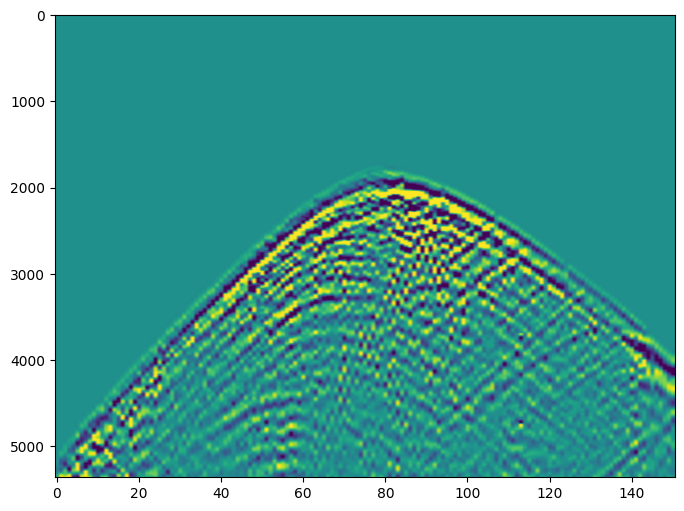

In [3]:
d_obs = dataset_plus[80][0]
plt.imshow(d_obs.T, aspect='auto', vmin=-5, vmax=5)

In [4]:
print(velmodel.vp.min()*1000/10/2000)
model.vp.data.min()*1000/10/2000

0.06019417475728155


Data(0.06019416, dtype=float32)

In [5]:
dataset.x_coords                                                

array([0.  , 0.  , 0.  , ..., 0.39, 0.39, 0.39])

In [6]:
dataset.opposite_x

array([40.63, 40.64, 40.64, ..., 41.26, 41.26, 41.26])

In [7]:
print(dataset.opposite_elev)

[ 16.85  17.85  18.85 ... 160.83 161.83 162.83]


In [8]:
len(dataset)

107

In [9]:
d, a, b, c, f = dataset[52]
print(a, b, c, f)

0.19 63.88 [40.63 40.62 40.63 40.63 40.63 40.63 40.64 40.63 40.64 40.64 40.64 40.64
 40.64 40.65 40.66 40.66 40.67 40.68 40.69 40.71 40.71 40.71 40.71 40.71
 40.72 40.72 40.71 40.71 40.71 40.71 40.71 40.72 40.73 40.74 40.75 40.78
 40.78 40.78 40.79 40.8  40.8  40.8  40.8  40.8  40.8  40.82 40.83 40.85
 40.86 40.87 40.89 40.89 40.9  40.9  40.9  40.9  40.93 40.91 40.91 40.93
 40.96 40.97 40.97 40.97 40.97 41.   41.01 41.01 41.01 41.03 41.04 41.04
 41.04 41.04 41.04 41.05 41.08 41.08 41.08 41.08 41.08 41.08 41.1  41.11
 41.11 41.12 41.12 41.15 41.15 41.15 41.15 41.15 41.15 41.16 41.16 41.16
 41.18 41.18 41.18 41.18 41.19 41.19 41.19 41.19 41.19 41.19 41.19 41.19
 41.19 41.19 41.21 41.21 41.21 41.22 41.22 41.21 41.19 41.21 41.22 41.22
 41.22 41.23 41.23 41.23 41.23 41.23 41.23 41.23 41.23 41.23 41.23 41.23
 41.23 41.23 41.23 41.25 41.23 41.25 41.25 41.25 41.25 41.25 41.25 41.25
 41.25 41.25 41.25 41.25 41.25 41.25 41.26 41.26 41.26 41.26] [  9.85  10.85  11.85  12.85  13.85  14.85  15.85  

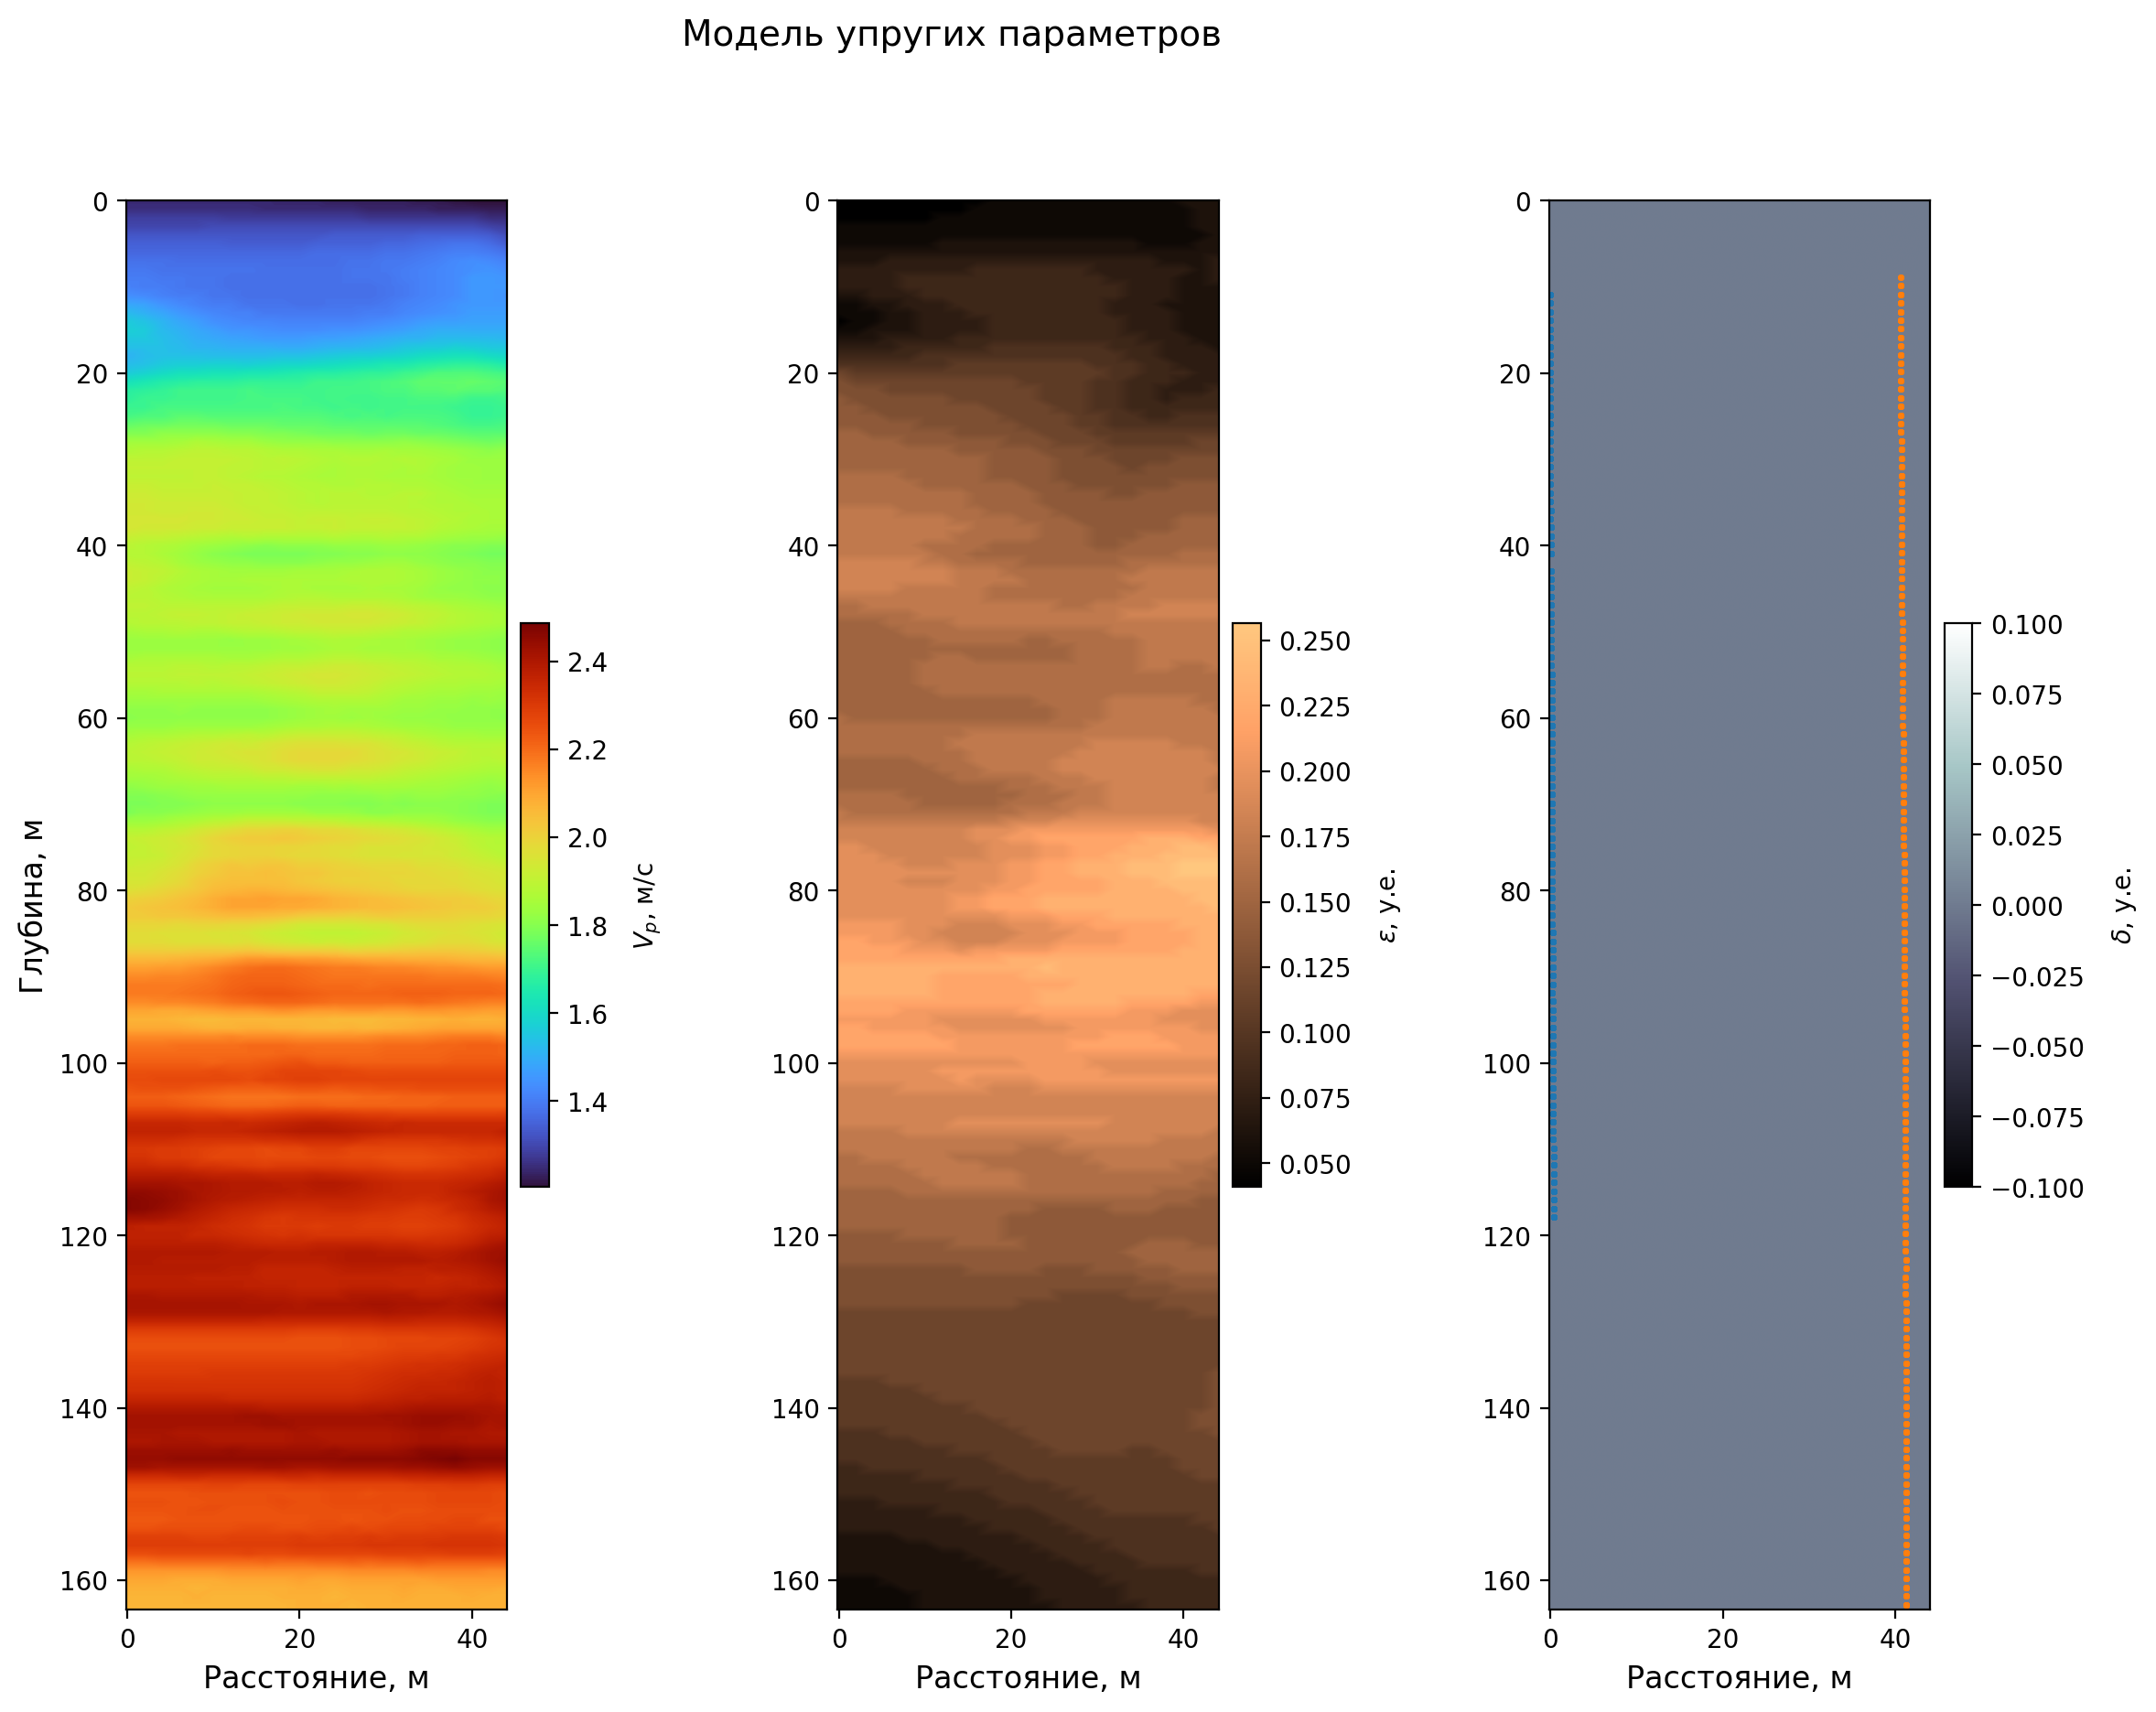

In [10]:
velmodel.plot_whole(show=False)
# plt.gcf().set_figheight(6)
# plt.gcf().set_figwidth(8)
plt.gca().scatter(dataset.x_coords, dataset.elevations, s=2)
plt.gca().scatter(dataset.opposite_x, dataset.opposite_elev, s=2)

plt.show()

In [11]:
from devito import mmin
print(velmodel.vp.min())
print(mmin(model.vp))

1.203883495145631
1.2038832902908325


In [12]:
model.origin

(np.float32(-0.1541), np.float32(-0.0))

In [13]:
print(velmodel.vp.shape)

(3270, 885)


In [14]:
print(model.grid.shape)

(np.int64(1885), np.int64(4270))


In [15]:
print(model.critical_dt)
print(TMAX/model.critical_dt)

0.009329
10719.263


In [16]:
d_obs, sx, sz, rec_x, rec_z = dataset[30]
t0 = 0
tn = 50.0

src_pos = np.array([sx, sz])[None, :]
rec_pos = np.vstack([rec_x, rec_z]).T
geometry = AcquisitionGeometry(
    model, rec_pos, src_pos,
    t0, tn, f0=0.5, src_type='Ricker'
)
solver = VTIWaveSolver(model, geometry, space_order=SO)
d_syn = Receiver(name='d_syn', grid=model.grid, time_range=geometry.time_axis,
                     coordinates=geometry.rec_positions)
solver.forward(save=False, rec=d_syn)
residual = Receiver(name='residual', grid=model.grid, time_range=geometry.time_axis,
                coordinates=geometry.rec_positions)
residual.data[:] = d_syn.data[:] - d_obs.T
srca, v, summary = solver.adjoint(rec=residual)

(5361, 153)
(5361, 153)


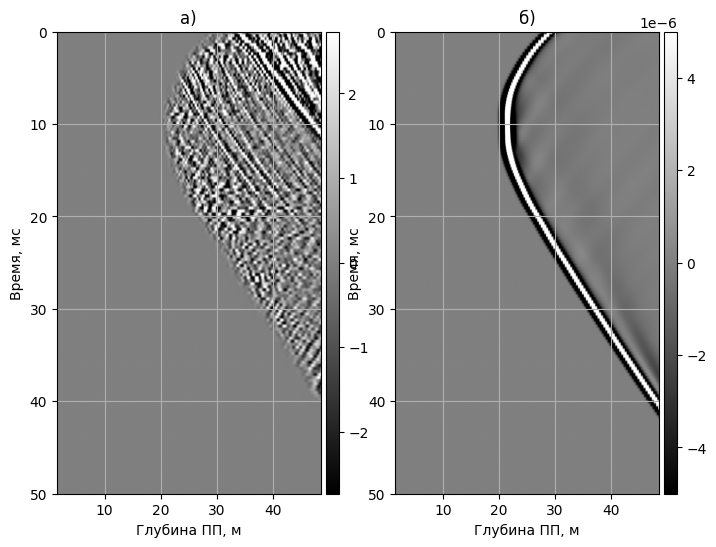

In [17]:
from examples.seismic.plotting import plot_shotrecord
fig, axs = plt.subplots(1, 2)
plot_shotrecord(residual.data[:], extent=[1.5, 48.5, tn, 0], ax=axs[0], ti='а)')
plot_shotrecord(d_syn.data[:], extent=[1.5, 48.5, tn, 0], ax=axs[1], ti='б)', scale=5e-6)
plt.show()

In [18]:
from scipy.signal.windows import tukey

def left_taper_tukey(signal, alpha=0.5):
    """
    Taper the left side of a signal using a Tukey window.
    
    Args:
        signal (np.ndarray): Input signal (gradient).
        alpha (float): Shape parameter of the Tukey window (0=rectangular, 1=Hann).
    
    Returns:
        np.ndarray: Tapered signal.
    """
    n = len(signal)
    signal[0] = 0.
    window = tukey(n * 2, alpha=alpha)[:n]  # Take left half of symmetric window
    return signal * window, window

def right_taper_tukey(signal, start_index, alpha=0.5):
    n = len(signal)
    
    # Calculate the length of the taper section needed
    taper_length = n - start_index
    
    if taper_length <= 0:
        # No tapering needed, return original signal
        return signal, np.ones(n)
    
    # Generate a full Tukey window to extract the slope portion
    full_window = tukey(n * 2, alpha=alpha)
    right_half = full_window[n:]
    
    # Find where the slope actually starts (where window < 1.0)
    slope_start_idx = np.where(right_half < 1.0)[0]
    if len(slope_start_idx) > 0:
        slope_start = slope_start_idx[0]
        slope_window = right_half[slope_start:]
    else:
        # If no slope found (alpha=0), use the entire right half
        slope_window = right_half
    
    # Take only the portion we need for our taper
    slope_window = slope_window[:taper_length]
    
    # Create the full window
    window = np.ones(n)
    window[start_index:start_index + len(slope_window)] = slope_window
    window[start_index + len(slope_window):] = 0
    # Apply the window to the signal
    tapered_signal = signal * window
    
    return tapered_signal, window

def minimal_phase_geometry(geometry, model, src_pos, rec_pos, tn):
    wav_data = np.array(geometry.src.data).ravel() + np.random.uniform(low=-0.00001, high=0.00001)
    spec = fft(wav_data)
    z_sup = hilbert(np.log(np.abs(spec)))
    arg_s_m = np.imag(z_sup)
    spec_s_m = np.abs(spec) * np.exp(-1j * arg_s_m)
    s_m = ifft(spec_s_m).real
    s_m2, window = right_taper_tukey(s_m, 4000, alpha=0.1)
    geometry_new = AcquisitionGeometry(model, rec_pos, src_pos,
                                       t0=0.0, tn=tn, src_type=None, wav_data=s_m2)
    return geometry_new

In [19]:
def set_wavelet_in_geometry(geometry, wavelet_1d):
    """
    geometry.src.data expects (nt, nsrc). We pass the same time series for each source (nsrc==1 here).
    wavelet_1d: shape (nt,)
    """
    w = np.asarray(wavelet_1d).reshape(-1, 1)
    geometry._src_type = None          # let us override with raw samples
    geometry.wav_data = w.reshape(-1)  # keep for our own bookkeeping
    geometry.src.data[:] = w

def forward_data(model, geometry, solver):
    """
    Return synthetic receiver data y = G f for the current geometry.src.data.
    """
    d_syn = Receiver(name='d_syn',
                     grid=model.grid,
                     time_range=geometry.time_axis,
                     coordinates=geometry.rec_positions)
    solver.forward(vp=model.vp, src=geometry.src, rec=d_syn, save=False)
    return np.array(d_syn.data)

def adjoint_to_source(model, geometry, solver, rec_traces):
    """
    Apply G^T to 'rec_traces' (shape (nt, nrec)), i.e. inject at receivers, backprop, sample at source.
    Returns a 1D array of length nt (B^T L^{-T} S^T rec_traces).
    """
    d = Receiver(name='d', grid=model.grid, time_range=geometry.time_axis,
                 coordinates=geometry.rec_positions)
    d.data[:] = rec_traces
    srca, _, _ = solver.adjoint(vp=model.vp, rec=d)  # srca shape: (nt, nsrc) -> we use a single source
    return np.array(srca.data).reshape(-1)

# --- Right-hand side b = G^T W^T W d
def precompute_b(model, geometry, solver, d_obs):
    """
    d_obs: observed data shaped (nrec, nt) or (nt, nrec). We'll accept your dataset shape.
    """
    # Devito expects (nt, nrec)
    if d_obs.shape[0] != geometry.time_axis.num:
        d_obs_tn = d_obs.T
    else:
        d_obs_tn = d_obs
    b = adjoint_to_source(model, geometry, solver, d_obs_tn)     # G^T W d  (W is self-adjoint)
    return b

# --- Linear operator apply: A v = G^T W G v + lam * v
def apply_A(model, geometry, solver, v, lam=0.0):
    set_wavelet_in_geometry(geometry, v)
    y = forward_data(model, geometry, solver)                 # y = G v  (nt, nrec)
    srca = adjoint_to_source(model, geometry, solver, y)    # G^T W y
    srca[0] = 0.
    # srca, window = left_taper_tukey(srca.reshape(-1), alpha=0.05)
    return srca.reshape(-1) + lam * v

def min_phase_wavelet(wav_data):
    spec = fft(wav_data)
    z_sup = hilbert(np.log(np.abs(spec)))
    arg_s_m = np.imag(z_sup)
    spec_s_m = np.abs(spec) * np.exp(-1j * arg_s_m)
    s_m = ifft(spec_s_m).real
    return s_m

In [20]:
def calculate_step_size(misfit, h):
    # Compute numerator and denominator for step size
    numerator = np.dot(misfit.reshape(-1), h.reshape(-1))
    denominator = np.dot(h.reshape(-1), h.reshape(-1))
    return numerator / denominator

from scipy.signal.windows import tukey

def left_taper_tukey(signal, alpha=0.5):
    """
    Taper the left side of a signal using a Tukey window.
    
    Args:
        signal (np.ndarray): Input signal (gradient).
        alpha (float): Shape parameter of the Tukey window (0=rectangular, 1=Hann).
    
    Returns:
        np.ndarray: Tapered signal.
    """
    n = len(signal)
    signal[0] = 0.
    window = tukey(n * 2, alpha=alpha)[:n]  # Take left half of symmetric window
    return signal * window, window

In [ ]:
from config import TMAX, PATH_WAVELETS
SO = 4
t0 = 0
tn = 50.0

# Set up model and geometry
model, dataset, dataset_dsub, velmodel = setup_model_and_geometry(path_data=PATH_DATA_DPLUS)

dataset._dt_r = model.critical_dt
print(model.critical_dt)
dataset._t_max_r = tn
dataset.resample_on()

max_iter = 5
lam = 1e-4

for k in range(0, len(dataset)):
    d_obs, sx, sz, rec_x, rec_z = dataset[k]
    mask = d_obs != 0
    mask = mask.astype('float')
    d_obs /= np.linalg.norm(d_obs)
    f0 = estimate_centroid_frequency_gather(d_obs.T, model.critical_dt) / 1e3
    print(f"[. shot {k}] Estimated gather centroid frequency: {f0*1e3:.2f} Hz, Wavelet length: {1/f0:.2f} ms")

    # Geometry / solver
    src_pos = np.array([sx, sz])[None, :]
    rec_pos = np.vstack([rec_x, rec_z]).T
    geometry = AcquisitionGeometry(
        model, rec_pos, src_pos,
        t0, tn, f0=f0, src_type='Ricker'
    )
    geometry = minimal_phase_geometry(geometry, model, src_pos, rec_pos, tn)
    geometry.src.show()
    solver = VTIWaveSolver(model, geometry, space_order=SO)

    current_wavelet = geometry.src.data[:].reshape(-1)
    prev_wavelet = current_wavelet.copy()

    b = precompute_b(model, geometry, solver, d_obs*mask)
    b, _ = left_taper_tukey(b, alpha=0.01)
    # # b[:2] = 0
    # Initial gradient g0 = A f0 - b
    Af = apply_A(model, geometry, solver, current_wavelet, lam=lam)
    g = Af - b
    g_prev = None

    for i in range(max_iter):
        # Exact steepest-descent line search for i==0, else Barzilai–Borwein
        if i == 0:
            # q = A g
            Ag = apply_A(model, geometry, solver, g, lam=lam)
            denom = np.dot(g, Ag) + 1e-18
            alpha = np.dot(g, g) / denom
            # alpha *= 0.5
        else:
            s = current_wavelet - prev_wavelet
            y = g - g_prev
            sy = np.dot(s, y)
            yy = np.dot(y, y) + 1e-18
            if abs(sy) > 1e-18:
                # Use BB-1 (often more aggressive); you can switch to BB-2 by using sy/yy
                alpha = np.dot(s, s) / sy
                # Optional safeguard
                # alpha = np.clip(alpha, 1e-6, 1e6)
            else:
                # Fallback to small step if curvature is poor
                alpha = 1e-3

        prev_wavelet = current_wavelet
        g_prev = g
        current_wavelet = current_wavelet - alpha * g

        Af = apply_A(model, geometry, solver, current_wavelet, lam=lam)
        g = Af - b

        rel_grad = np.linalg.norm(g) / (np.linalg.norm(b) + 1e-18)
        misfit = 0.5 * np.dot(current_wavelet, Af) - np.dot(current_wavelet, b)  # J up to const (quadratic form)
        print(f"    iter {i+1:02d}: alpha={alpha:.3e}, rel||g||={rel_grad:.3e}, approx J={misfit:.3e}")
        plt.plot(geometry.time_axis.time_values, current_wavelet)
        # Simple stopping
        if rel_grad < 5e-3:
            print("    Converged on wavelet update.")
            break

    estimated_wavelet = current_wavelet.copy()
    minph_wavelet = min_phase_wavelet(estimated_wavelet)
    plt.plot(geometry.time_axis.time_values, minph_wavelet)
    plt.show()
    np.save(f"{PATH_WAVELETS}/wavelet_{k}_norm_alt.npy", estimated_wavelet)
    np.save(f"{PATH_WAVELETS}/wavelet_{k}_minph_alt.npy", minph_wavelet)
    # np.save(f"{PATH_WAVELETS}/wavelet_{k}_norm.npy", estimated_wavelet)
    # np.save(f"{PATH_WAVELETS}/wavelet_{k}_minph.npy", minph_wavelet)

(d_syn(time, p_d_syn),
 p(t, x, y),
 PerformanceSummary([(PerfKey(name='section0', rank=None),
                      PerfEntry(time=3.467025000000087, gflopss=0.0, gpointss=0.0, oi=0.0, ops=0, itershapes=[])),
                     (PerfKey(name='section1', rank=None),
                      PerfEntry(time=1.8058279999999658, gflopss=0.0, gpointss=0.0, oi=0.0, ops=0, itershapes=[])),
                     (PerfKey(name='section2', rank=None),
                      PerfEntry(time=1.7702940000000489, gflopss=0.0, gpointss=0.0, oi=0.0, ops=0, itershapes=[]))]))

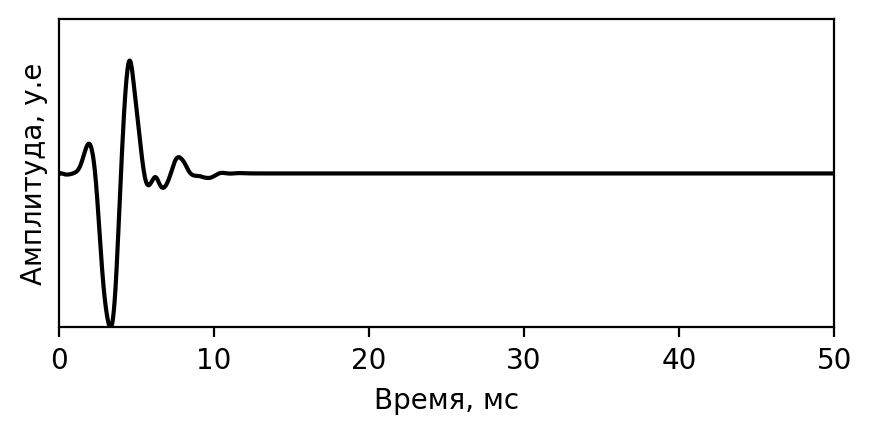

In [90]:
wav_data = np.load(f"{PATH_WAVELETS}/wavelet_{50}_norm_alt.npy")
wav_data, _ = right_taper_tukey(wav_data, 300, alpha=0.2)
wav_data /= np.max(np.abs(wav_data))

fig, axs = plt.subplots(1, 1, figsize=(5, 2), dpi=200)
plt.plot(geometry.time_axis.time_values, wav_data, c='k')
axs.set_xlim(0, 50)
axs.set_ylim([-1, 1])
axs.set_yticks([])
axs.set_yticklabels([])
axs.set_ylabel("Амплитуда, у.е")

axs.set_xlabel("Время, мс")
plt.show()

In [64]:
d_obs, sx, sz, rec_x, rec_z = dataset_plus[49]
t0 = 0
tn = 50.0

src_pos = np.array([sx, sz])[None, :]
rec_pos = np.vstack([rec_x, rec_z]).T
geometry = AcquisitionGeometry(
    model, rec_pos, src_pos,
    t0, tn, f0=0.5, src_type=None, wav_data=wav_data,
)
solver = VTIWaveSolver(model, geometry, space_order=SO)
d_syn = Receiver(name='d_syn', grid=model.grid, time_range=geometry.time_axis,
                     coordinates=geometry.rec_positions)
solver.forward(save=False, rec=d_syn)

(d_syn(time, p_d_syn),
 p(t, x, y),
 PerformanceSummary([(PerfKey(name='section0', rank=None),
                      PerfEntry(time=2.2081179999999625, gflopss=0.0, gpointss=0.0, oi=0.0, ops=0, itershapes=[])),
                     (PerfKey(name='section1', rank=None),
                      PerfEntry(time=0.48501800000000156, gflopss=0.0, gpointss=0.0, oi=0.0, ops=0, itershapes=[])),
                     (PerfKey(name='section2', rank=None),
                      PerfEntry(time=0.4538569999999518, gflopss=0.0, gpointss=0.0, oi=0.0, ops=0, itershapes=[]))]))

In [77]:
rec_z.max()
rec_z.min()
sz

np.float64(60.88)

(5361, 154)
(5361, 154)


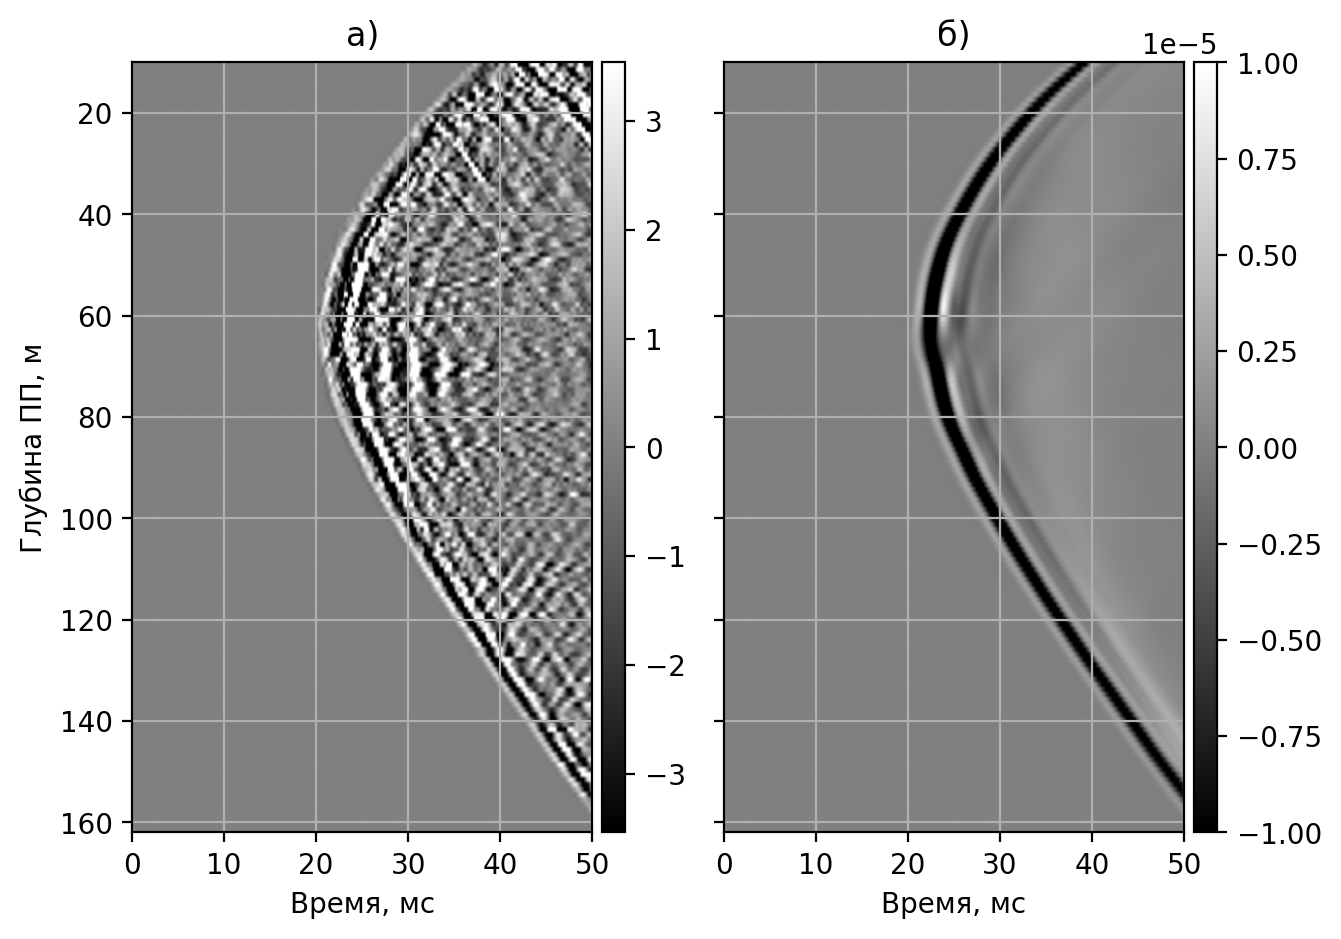

In [84]:
d_obs, sx, sz, rec_x, rec_z = dataset[49]
from examples.seismic.plotting import plot_shotrecord
fig, axs = plt.subplots(1, 2, dpi=200, figsize=(7, 5))
plot_shotrecord(d_obs.T, extent=[0, 50.0, 162, 10], ax=axs[0], ti='а)')
plot_shotrecord(d_syn.data[:], extent=[0, 50.0, 162, 10], ax=axs[1], ti='б)', scale=1e-5)
axs[1].set_ylabel('')
axs[1].set_yticklabels([])
# axs[1].set_yticklabels([])

axs[0].set_ylabel("Глубина ПП, м")
axs[0].set_xlabel("Время, мс")
axs[1].set_xlabel("Время, мс")


plt.show()

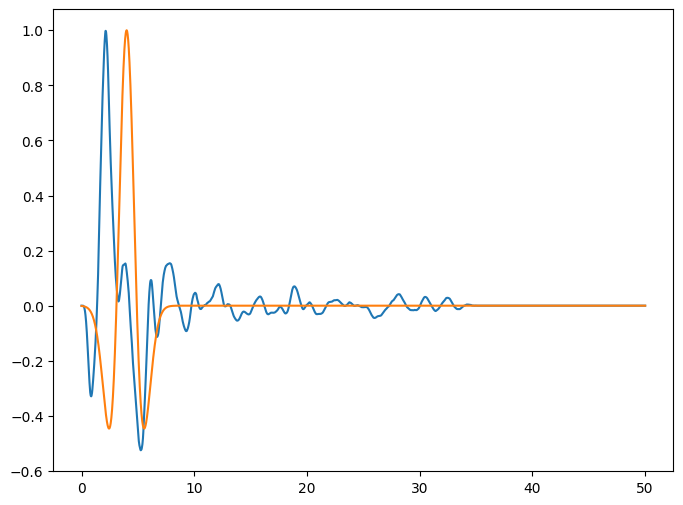

In [20]:
plt.plot(geometry.time_axis.time_values, left_taper_tukey(srca.data[:].reshape(-1)*25, alpha=0.02)[0])
plt.plot(geometry.time_axis.time_values, geometry.src.data[:])
plt.show()

In [ ]:
max_iter = 5
beta = 0.001

for k in range(len(dataset)):
    d_obs, sx, sz, rec_x, rec_z = dataset[k]
    f0 = estimate_centroid_frequency_gather(d_obs.T, model.critical_dt) / 1e3
    print(f"Estimated gather centroid frequency: {f0*1e3:.2f} Hz, Wavelet length: {1/f0:.2f} ms")
    src_pos = np.array([sx, sz])[None, :]
    rec_pos = np.vstack([rec_x, rec_z]).T
    geometry = AcquisitionGeometry(
        model, rec_pos, src_pos,
        t0, tn, f0=f0, src_type='Ricker'
    )
    current_wavelet = geometry.src.data[:].reshape(-1)
    initial_wavelet = np.copy(current_wavelet)
    scale_factor = 1.
    for i in range(max_iter):
        # Forward modeling
        geometry = AcquisitionGeometry(
            model, rec_pos, src_pos,
            t0, tn, f0=0.25, src_type=None, wav_data=current_wavelet
        )
        solver = VTIWaveSolver(model, geometry, space_order=SO)
        d_syn = Receiver(name='d_syn', grid=model.grid, time_range=geometry.time_axis,
                        coordinates=geometry.rec_positions)
        solver.forward(vp=model.vp, rec=d_syn, save=False)
        residual = Receiver(name='residual', grid=model.grid, time_range=geometry.time_axis,
                    coordinates=geometry.rec_positions)
        # if i == 0:
        scale_factor = np.linalg.norm(d_obs.ravel())/np.linalg.norm(np.array(d_syn.data[:]).ravel())
        print("Scale: ", scale_factor, np.quantile(d_obs, 0.99), scale_factor*np.quantile(np.array(d_syn.data[:]), 0.99))
        residual.data[:] = scale_factor*d_syn.data - d_obs.T
        
        # Compute gradient (adjoint source)
        srca, _, _ = solver.adjoint(vp=model.vp, rec=residual)
        gradient = srca.data
        gradient_tapered, window = left_taper_tukey(gradient.reshape(-1), alpha=0.05)
        gradient_tapered += beta*(current_wavelet - initial_wavelet)
        misfit = geometry.src.data.reshape(-1) - gradient_tapered.reshape(-1)
        alpha = 0.5*calculate_step_size(misfit, gradient)
        # Update wavelet
        current_wavelet = current_wavelet - alpha * gradient_tapered
        print(f"Iter {i}: Alpha = {alpha} Misfit = {np.dot(misfit.reshape(-1), misfit.reshape(-1))**2:.4e}")
    plt.plot(geometry.time_axis.time_values, current_wavelet/np.max(np.abs(current_wavelet)))
    plt.plot(geometry.time_axis.time_values, initial_wavelet/np.max(np.abs(initial_wavelet)))
    plt.show()
    np.save(f"../adjoint_wavelets/wavelet_{k}_norm.npy", current_wavelet)
    np.save(f"../adjoint_wavelets/wavelet_scale_{k}.npy", scale_factor)

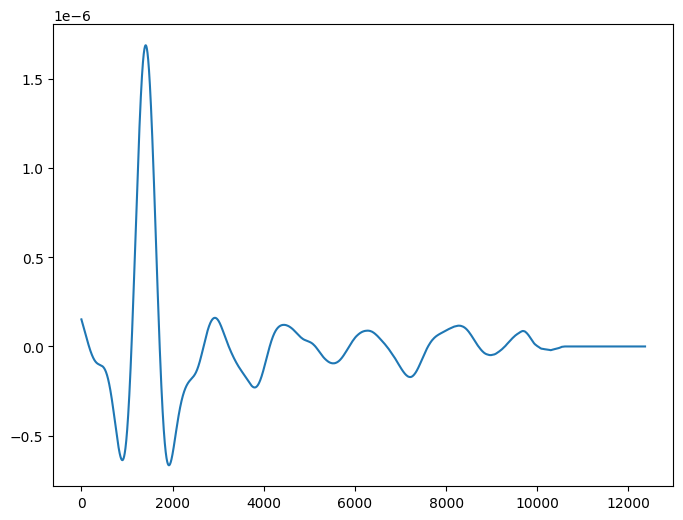

In [47]:
# plt.imshow(d_syn.data[:], aspect='auto')
# plt.imshow(d_obs.T, aspect='auto')

plt.plot(srca.data[:][1:])

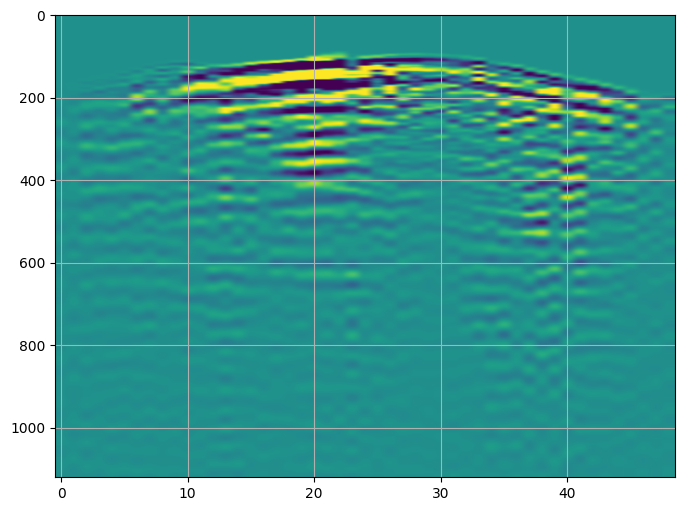

In [8]:

d_obs, sx, sz, rec_x, rec_z = dataset[20]
qa = np.quantile(d_obs, 0.99)

plt.imshow(d_obs.T, aspect='auto', vmin=-qa, vmax=qa)
plt.grid()
plt.show()

Operator `Forward` ran in 4.04 s


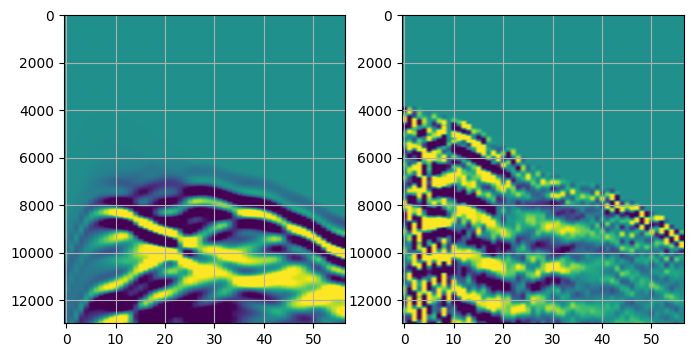

Operator `Forward` ran in 4.04 s


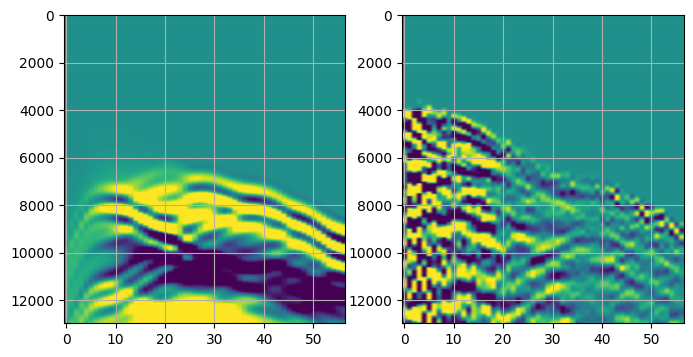

Operator `Forward` ran in 4.04 s


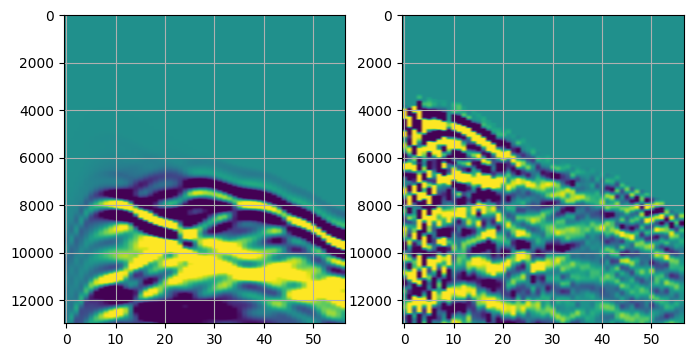

Operator `Forward` ran in 4.04 s


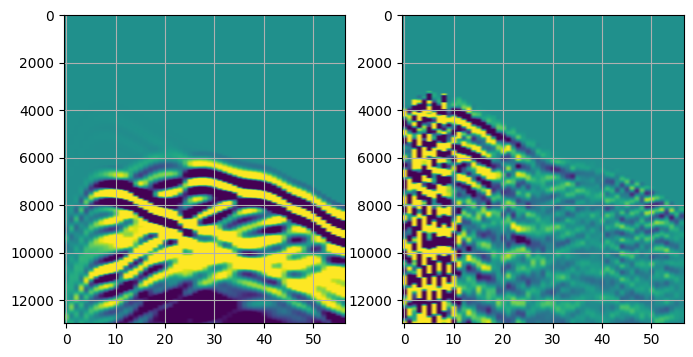

In [ ]:
N = 40
t0 = 0
tn = TMAX
for i in range(len(dataset)):
    d_obs, sx, sz, rec_x, rec_z = dataset[i]
    wav_data = np.load(f"Mex_wavelet_{i}_norm.npy")
    src_pos = np.array([sx, sz])[None, :]
    rec_pos = np.vstack([rec_x, rec_z]).T
    geometry = AcquisitionGeometry(
        model, rec_pos, src_pos,
        t0, tn, f0=0.25, src_type=None, wav_data=wav_data
    )
    solver = AcousticWaveSolver(model, geometry, space_order=SO)
    d_syn = Receiver(name='d_syn', grid=model.grid, time_range=geometry.time_axis,
                        coordinates=geometry.rec_positions)
    solver.forward(vp=model.vp, save=False, rec=d_syn)
    scale_factor = np.linalg.norm(d_obs.ravel())/np.linalg.norm(np.array(d_syn.data[:]).ravel())
    np.save(f"Mex_wavelet_{i}_norm_scalar.npy", scale_factor)
    
    fig, axs = plt.subplots(1, 2, figsize=(8, 4))
    qa = np.quantile(d_obs, 0.95)
    axs[0].imshow(scale_factor*d_syn.data[:], aspect='auto', vmin=-qa, vmax=qa)
    axs[0].grid()
    axs[1].imshow(d_obs.T, aspect='auto', vmin=-qa, vmax=qa)
    axs[1].grid()
    plt.show()
# srca, v, summary = solver.adjoint(vp=model.vp, rec=residual)

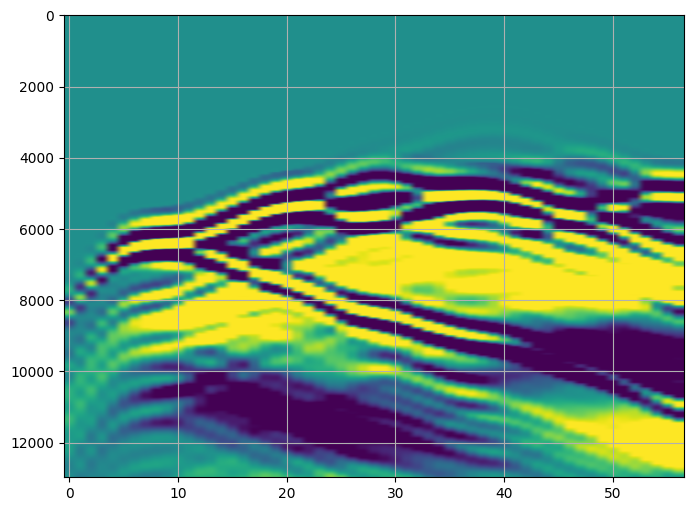

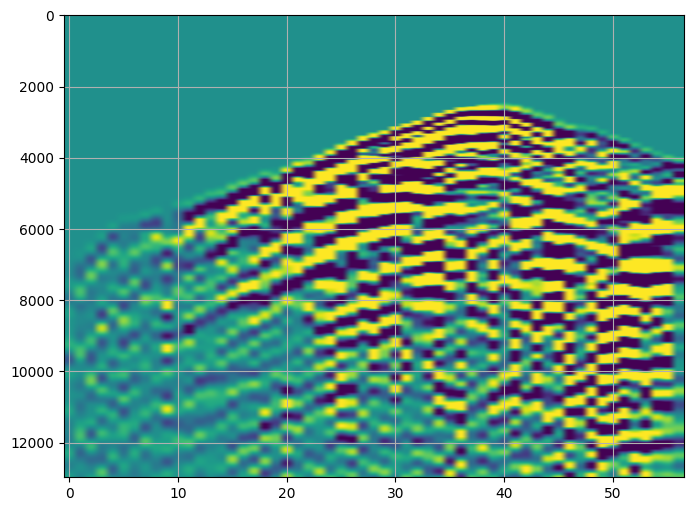

In [12]:
from matplotlib import pyplot as plt
# d_obs, sx, sz, rec_x, rec_z = dataset[20]
qa = np.quantile(d_obs, 0.9)
# qa = np.quantile(np.array(d_syn.data[:]).ravel(), 0.99)
plt.imshow(d_syn.data[:], aspect='auto', vmin=-qa, vmax=qa)
plt.grid()
plt.show()
plt.imshow(d_obs.T, aspect='auto', vmin=-qa, vmax=qa)
plt.grid()
plt.show()